In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import scipy as sp
from scipy import stats
import glob
import os

In [2]:
methodOrder = ["WaveletTree", "RLBWT", "RBBWT", "RBBWT_1S"]
mypalette = sns.color_palette(None, 4)
mypalette[0], mypalette[1] = mypalette[1], mypalette[0]
classifierOrder = ["Centrifuger", "Kaiju", "Kraken2"]

# Rank query speed (ns) and space (byets) for  genus 445 (Legionella) genomes (without plasmid)'s BWT

In [3]:
# BWT length 652270131
methodv = []
speedv = []
spacev = []
sigmav = []

for sheet in ["Speed", "Space"]:
    df = pd.read_excel("Genus445/Efficiency.xlsx", sheet_name=sheet)
    cols = list(df.columns)
    for i,r in df.iterrows():
        sigma=r["sigma"]
        for c in cols:
            if (c == "sigma"):
                continue
            if (sheet == "Speed"):
                methodv.append(c)
                sigmav.append(sigma)
                speedv.append(r[c])
            else: # sheet == Space
                spacev.append(r[c]/(652270131) * 8) # bits per character
efficiencyDf = pd.DataFrame({ "Method":methodv, "Speed":speedv, "Space":spacev, "sigma":sigmav})


In [4]:
efficiencyDf

,Method,Speed,Space,sigma
0,WaveletTree,7.59312,2.500022,4.0
1,RLBWT,86.69610,1.934747,4.0
2,RBBWT,21.61710,1.243184,4.0
3,RBBWT_1S,17.80940,1.786594,4.0
4,WaveletTree,11.76900,3.750052,8.0
5,RLBWT,87.65710,2.098912,8.0
6,RBBWT,34.08410,1.786675,8.0
7,RBBWT_1S,21.46580,2.330055,8.0
8,WaveletTree,15.31250,5.000111,16.0
9,RLBWT,89.54890,2.263142,16.0


<>:11: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:11: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/c8/zsnj8w1x221_yh1cvqwq68n80000gn/T/ipykernel_57050/3661027921.py:11: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.set(xlabel = "$\sigma$", ylabel="Rank query time (ns)")
/var/folders/c8/zsnj8w1x221_yh1cvqwq68n80000gn/T/ipykernel_57050/3661027921.py:20: SyntaxWarn

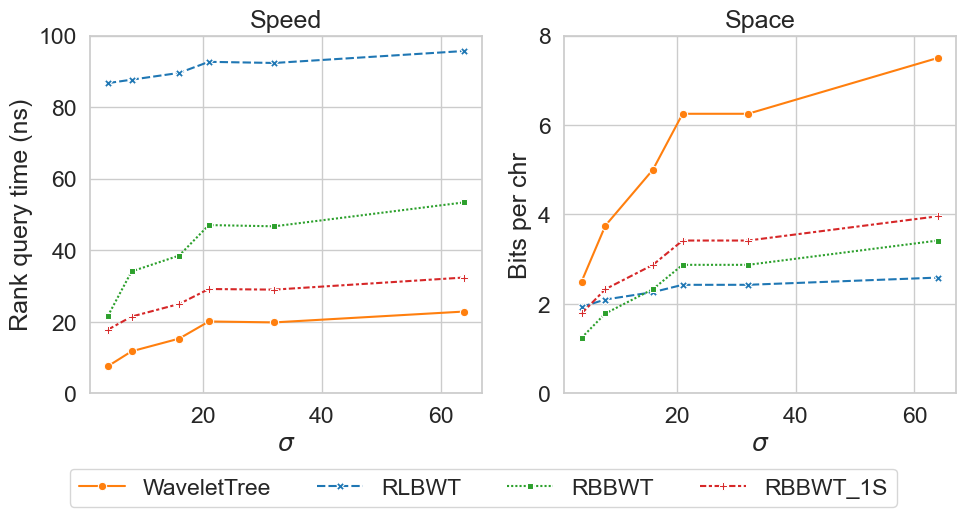

In [ ]:
sns.set(font_scale=1.5, style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax = sns.lineplot(x="sigma", y="Speed", hue="Method", style="Method", 
                  hue_order = methodOrder,
                  data=efficiencyDf[ efficiencyDf["Method"].isin(methodOrder)], markers=True, palette = mypalette,
                 ax = axes[0])
#ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set(ylabel="log(space)", xlabel="log(Copy)")
ax.set(title="Speed", ylim=(0, 100))
ax.set(xlabel = "$\sigma$", ylabel="Rank query time (ns)")
ax.get_legend().remove()
#ax.legend()

ax = sns.lineplot(x="sigma", y="Space", hue="Method", style="Method", 
                  hue_order = methodOrder,
                  data=efficiencyDf[ efficiencyDf["Method"].isin(methodOrder)], markers=True, palette = mypalette,
                 ax = axes[1])
ax.set(ylim=(0,8))
ax.set(title="Space", ylabel="Bits per chr", xlabel="$\sigma$")
h, l = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(handles=h, labels=l, loc="upper center", 
    bbox_to_anchor=(0.5, 0.05), ncols=4)

plt.tight_layout()
plt.savefig("Fig2_RBBWT.pdf", format="pdf", bbox_inches="tight")

# Simulated data

### Accuracy

In [5]:
methods = {"cfr": "Centrifuger", "kraken2": "Kraken2", "kaiju": "Kaiju"}
ranks = ["strain", "species", "genus", "family", "order", "class", "phylum"]
classifierOrder = ["Centrifuger", "Kaiju", "Kraken2"]
rankMaps = {}
for i, r in enumerate(ranks):
    rankMaps[r] = i
    
df = pd.DataFrame()
for m in methods:
    mdf = pd.read_csv("sim/%s_eval.out"%m, sep="\t")
    mdf["f1"] = 2 * mdf["precision"] * mdf["sensitivity"] / (mdf["precision"] + mdf["sensitivity"])
    mdf["method"] = methods[m]
    df = pd.concat([df, mdf], ignore_index=True)

In [108]:
df

,rank,true,predicted,cases,sensitivity,precision,uniq_true,uniq_pred,uniq_sensitivity,uniq_precision,f1,method
0,strain,147629,167731,1000000,0.1476,0.8802,147629,167731,0.1476,0.8802,0.252807,Centrifuger
1,species,330308,340947,1000000,0.3303,0.9688,330308,340947,0.3303,0.9688,0.492641,Centrifuger
2,genus,787074,792296,999726,0.7873,0.9934,787074,792296,0.7873,0.9934,0.878423,Centrifuger
3,family,923043,924748,997184,0.9256,0.9982,923043,924748,0.9256,0.9982,0.960530,Centrifuger
4,order,953132,954301,997732,0.9553,0.9988,953132,954301,0.9553,0.9988,0.976566,Centrifuger
5,class,962271,962974,993614,0.9685,0.9993,962271,962974,0.9685,0.9993,0.983659,Centrifuger
6,phylum,972847,973382,999746,0.9731,0.9995,972847,973382,0.9731,0.9995,0.986123,Centrifuger
7,strain,123215,155607,1000000,0.1232,0.7918,123215,155607,0.1232,0.7918,0.213224,Kraken2
8,species,268610,293079,1000000,0.2686,0.9165,268610,293079,0.2686,0.9165,0.415445,Kraken2
9,genus,755455,771350,999726,0.7557,0.9794,755455,771350,0.7557,0.9794,0.853130,Kraken2


In [ ]:
# Sort first by rank and method. Method should be sorted into the order as classifierOrder. Save to a tsv file.
df.sort_values(["rank", "method"], key=lambda x: x.map(rankMaps) if x.name=='rank' 
               else x.map({c:i for i,c in enumerate(classifierOrder)})).to_csv("pv_sim_accuracy.tsv", sep="\t")

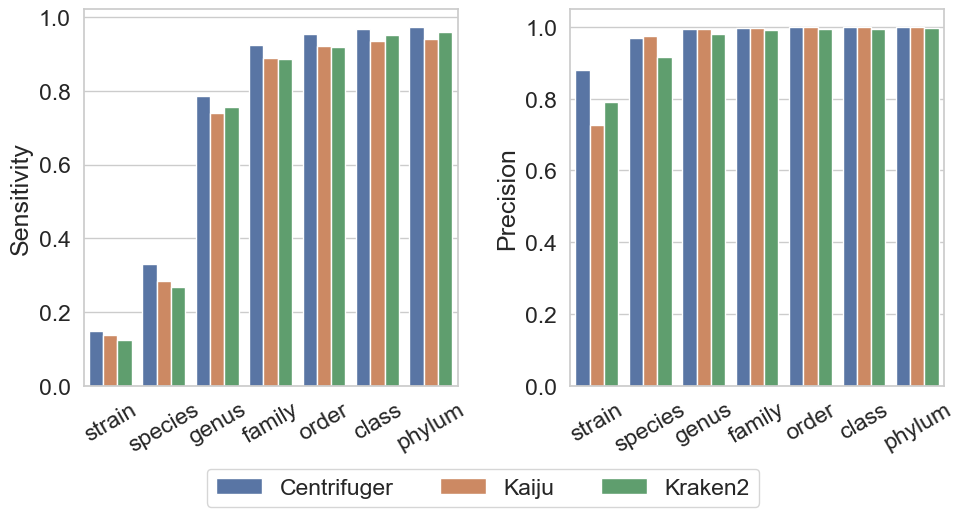

In [77]:
sns.set(font_scale=1.5, style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

for i, measure in enumerate(["sensitivity", "precision"]):#, "f1"]):  
    ax = sns.barplot(x="rank", y=measure, hue="method", data=df,
                     ax = axes[i], hue_order=classifierOrder)
    #snsFig.legend([])
    #snsFig.set(xlim=(0.95,1))
    ax.set(xlabel="Rank", ylabel=measure.capitalize())
    h, l = ax.get_legend_handles_labels()
    ax.legend().remove()
    ax.set(xlabel="")
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
fig.legend(handles=h, labels=l, loc="upper center", 
    bbox_to_anchor=(0.5, 0.05), ncols=len(classifierOrder))
plt.tight_layout()
plt.savefig("sim_ckk_accuracy.pdf", format="pdf", bbox_inches="tight")

## Speed and memory of simulated data (database pv)

Speed (running on t02 node) with 1 thread
Cfr: 5min32s load: 7s
Kaiju: 4min17s  load: 12s
Kraken2: 20s 

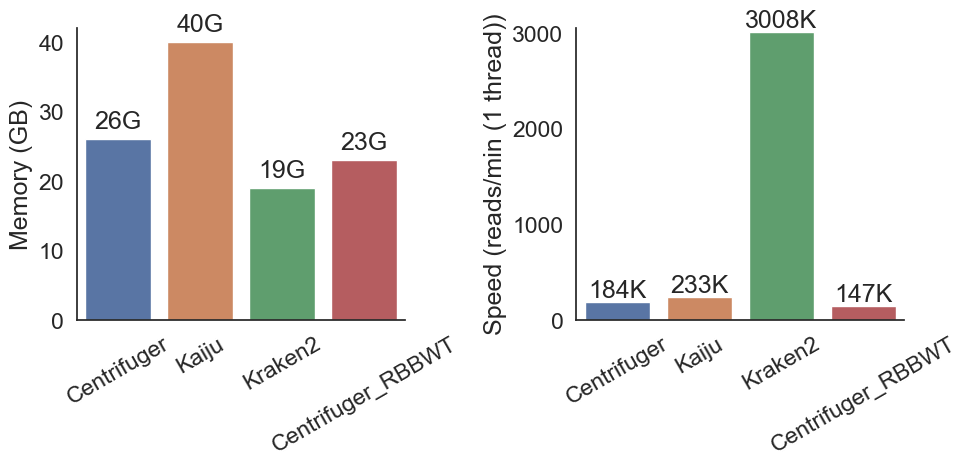

In [137]:
methodv = ["Centrifuger", "Kaiju", "Kraken2", "Centrifuger_RBBWT"]
speedv = [1000/(5*60+25)*60, 1000/(4*60+17)*60, 3008, 1000/(6*60+48)*60]
memoryv = [26, 40, 19, 23]

timeDf = pd.DataFrame({"Method":methodv, "Speed":speedv, "Memory":memoryv})
sns.set(font_scale=1.5, style="white")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

for i, measure in enumerate(["Memory", "Speed"]):  
    ax = sns.barplot(x="Method", y=measure, data=timeDf,
                     ax = axes[i], hue="Method")
    #snsFig.legend([])
    #snsFig.set(xlim=(0.95,1))
    #ax.legend()
    ax.set(xlabel = "")
    if (measure == "Memory"):
        ax.set(ylabel = "Memory (GB)")
        for i in range(len(methodv)):
            ax.text(i, memoryv[i]+1.5, "%dG"%(memoryv[i]), horizontalalignment="center")
    elif (measure == "Speed"):
        ax.set(ylabel = "Speed (reads/min (1 thread))", ylim=(0, 3050))
        for i in range(len(methodv)):
            ax.text(i, speedv[i]+50, "%dK"%(speedv[i]), horizontalalignment="center")
    ax.spines['right'].set_visible(False)  
    ax.spines['top'].set_visible(False)  
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
    
plt.tight_layout()
plt.savefig("sim_ckkc_time.pdf", format="pdf",bbox_inches="tight")

# simulated data set pv_genus1 (only keep one genome per genus)

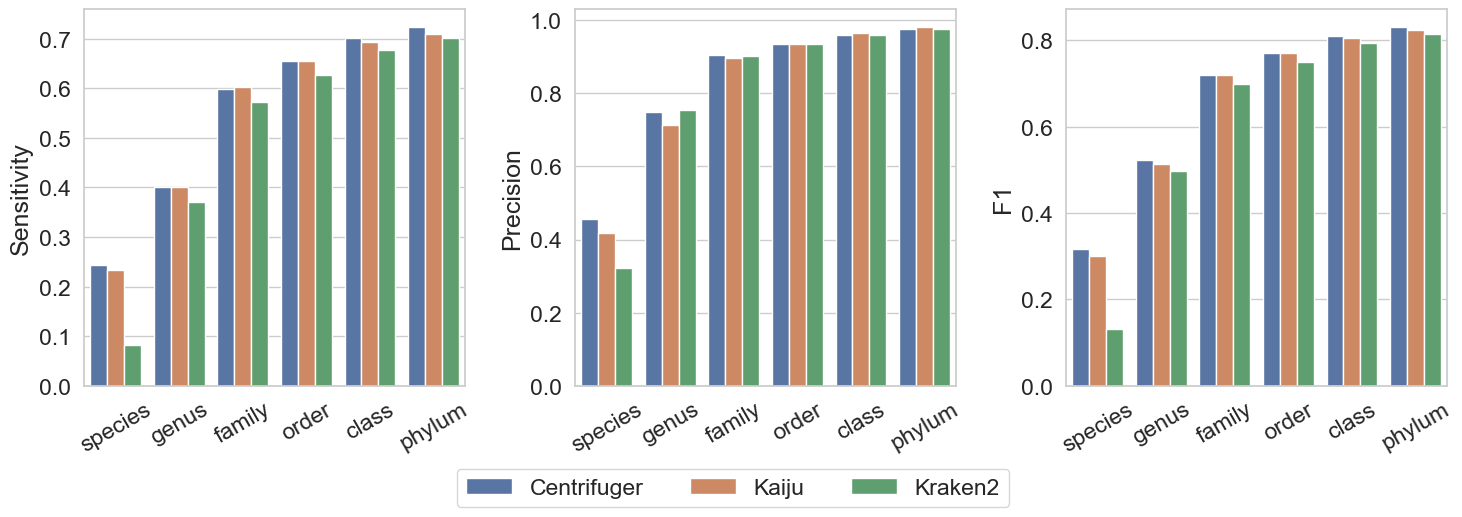

In [ ]:
methods = {"cfr": "Centrifuger", "kraken2": "Kraken2", "kaiju": "Kaiju"}
ranks = ["species", "genus", "family", "order", "class", "phylum"]
classifierOrder = ["Centrifuger", "Kaiju", "Kraken2"]
rankMaps = {}
for i, r in enumerate(ranks):
    rankMaps[r] = i
    
df = pd.DataFrame()
for m in methods.keys():
    mdf = pd.read_csv("sim_genus1/%s_eval.out"%m, sep="\t")
    mdf["method"] = methods[m]
    df = pd.concat([df, mdf], ignore_index=True)
df = df[ df["rank"] != "strain" ]
df["f1"] = 2 * df["precision"] * df["sensitivity"] / (df["precision"] + df["sensitivity"])

sns.set(font_scale=1.5, style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

h, l = None, None 
for i, measure in enumerate(["sensitivity", "precision", "f1"]):  
    #ax = sns.lineplot(x="rank", y=measure, hue="method", marker='o', data=df,
    #                 ax = axes[i])
    ax = sns.barplot(x="rank", y=measure, hue="method", data=df,
                     ax = axes[i], hue_order=classifierOrder)
    #snsFig.set(xlim=(0.95,1))
    ax.set(xlabel="Rank", ylabel=measure.capitalize())
    h, l = ax.get_legend_handles_labels()
    ax.legend([], [], frameon=False)
    ax.set(xlabel="")
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
fig.legend(handles=h, labels=l, loc="upper center", 
    bbox_to_anchor=(0.5, 0.05), ncols=len(classifierOrder))
plt.tight_layout()
plt.savefig("sim_genus1_ckk_accuracy.pdf", format="pdf", bbox_inches="tight")

# CAMI simulated

In [10]:
camiDf = pd.read_csv("sim_cami/cami_10samples_eval.out", sep="\t")
camiDf = camiDf[ camiDf["rank"] != "strain"]
camiDf["f1"] = 2 * camiDf["precision"] * camiDf["sensitivity"] / (camiDf["precision"] + camiDf["sensitivity"])

In [11]:
def hollowboxplot(data, x=None, y=None, hue=None, palette=None, ax=None, color=None, 
                  order=None, hue_order=None, jitter=True):
    snsFig = sns.boxplot(x=x, y=y, hue=hue, data=data, hue_order=hue_order, order=order,
                         showfliers = False, palette=palette, ax=ax)
    for i,box in enumerate([p for p in snsFig.patches if not p.get_label()]): 
        color = box.get_facecolor()
        box.set_edgecolor(color)
        box.set_facecolor("white")
        # iterate over whiskers and median lines
        for j in range(5*i,5*(i+1)):
             snsFig.lines[j].set_color(color)

    snsFig = sns.stripplot(x=x, y=y, hue=hue, data=data, hue_order=hue_order, order=order,
                         jitter=jitter, dodge=True, palette=palette, ax=snsFig)
    return snsFig

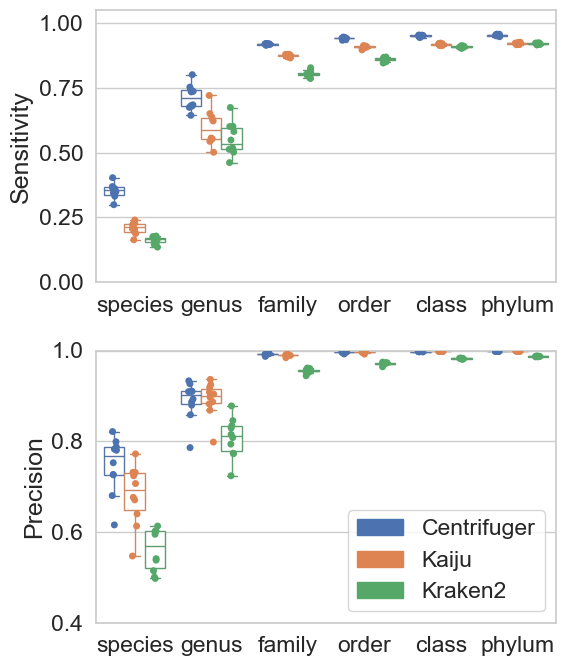

In [ ]:
sns.set(font_scale=1.5, style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7))

for i, measure in enumerate(["sensitivity", "precision"]):  
    ax = hollowboxplot(x="rank", y=measure, hue="method", data=camiDf,
                     ax = axes[i], hue_order=["centrifuger", "kaiju", "kraken2"])
    #ax = sns.stripplot(x="rank", y=measure, hue="method", data=camiDf,
    #                 dodge=True, s=1, ax=ax)
    ax.set(xlabel="", ylabel=measure.capitalize())
    
    if (measure == "precision"):
        patches = []
        for i, l in [[0, "Centrifuger"], [1, "Kaiju"], [2, "Kraken2"]]:
            patches.append( mpatches.Patch( color=sns.color_palette()[i], label=l ) )
        ax.legend( handles=patches, loc="best")
        ax.set(ylim=[0.4, 1])
    else:
        ax.legend([], [], frameon=False)
        ax.set_ylim([0, 1.05])
        ax.set_xlabel("")
    #for tick in ax.get_xticklabels():
    #    tick.set_rotation(30)
plt.tight_layout()
#plt.savefig("sim_cami_accuracy.pdf", format="pdf")
plt.savefig("Fig4_CAMI.pdf", format="pdf", bbox_inches="tight")

# SRA bacteria (100 inspecies, 100 in not-inspecies but in genus)

### In species: genus level

In [13]:
case = "inspecies"
folder = "bacteria_sra/%s"%(case)
measure = "sensitivity"
methods = {"Centrifuger":"cfr", "Kraken2":"kraken2", "Kaiju":"kaiju", "Centrifuger_genome":"cfr_genome"}
df = pd.DataFrame()
for m in methods:
    mdf = pd.read_csv("bacteria_sra/%s/genus_level/%s_genus_result.tsv"%(case, methods[m]), sep="\t",
                     header=None)
    mdf["method"] = m
    df = pd.concat([df, mdf], ignore_index=True)
df.columns = ["SRA", "rank", "sensitivity", "non-specific precision", "precision", "method"]

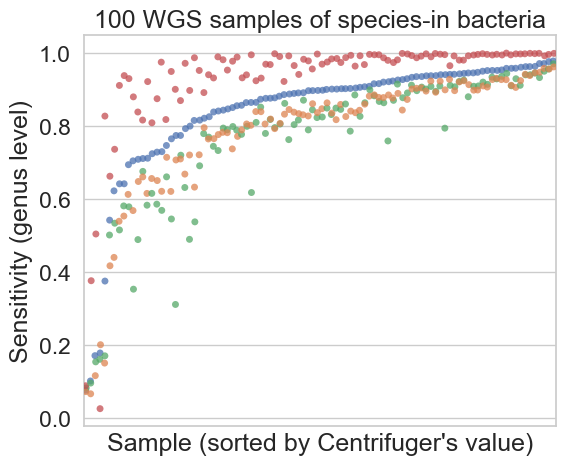

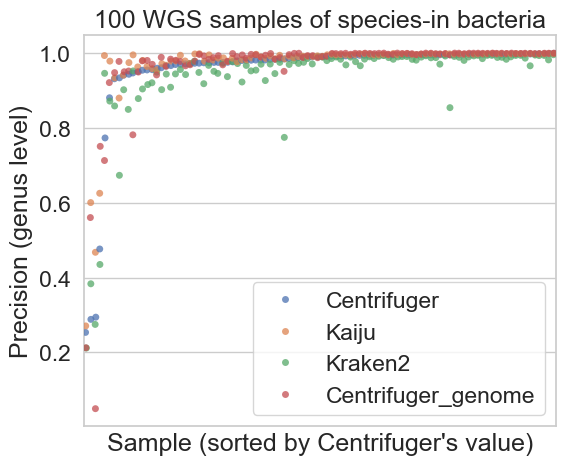

In [ ]:
for measure in ["sensitivity", "precision"]:
    sns.set(font_scale=1.5, style="whitegrid")
    fig = plt.figure(figsize=(6, 5))
    subdf = df[ df["method"] == "Centrifuger" ]
    sraList = list(subdf.sort_values(by=measure)["SRA"])
    ax = sns.stripplot(x="SRA", y = measure, hue="method", size=5, alpha=0.75,
                order = sraList, hue_order = classifierOrder + ["Centrifuger_genome"], data=df)
    ax.get_xaxis().set_ticks([])
    ax.set(xlabel = "Sample (sorted by Centrifuger's value)", 
           title="100 WGS samples of species-in bacteria",
          ylabel = "%s (genus level)"%(measure.capitalize()))
    if (measure == "sensitivity"):
        ax.legend([],[], frameon=False)
    else:
        ax.legend()
    plt.tight_layout()
    plt.savefig("SRA_%s_%s_genuslevel.png"%(case, measure), dpi=300)
    plt.show()

### In genus (species-not-in)

In [15]:
case = "ingenus"
folder = "bacteria_sra/%s"%(case)
measure = "sensitivity"
methods = {"Centrifuger":"centrifuger", "Kraken2":"kraken2", "Kaiju":"kaiju", "Centrifuger_genome":"cfr_genome"}
df = pd.DataFrame()
for m in methods:
    mdf = pd.read_csv("bacteria_sra/%s/%s_result.tsv"%(case, methods[m]), sep="\t",
                     header=None)
    mdf["method"] = m
    df = pd.concat([df, mdf], ignore_index=True)
df.columns = ["SRA", "rank", "sensitivity", "non-specific precision", "precision", "method"]
df["f1"] = 2 * df["precision"] * df["sensitivity"] / (df["precision"] + df["sensitivity"])

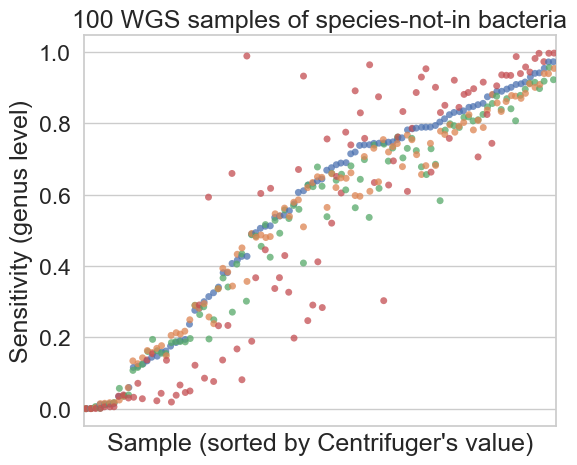

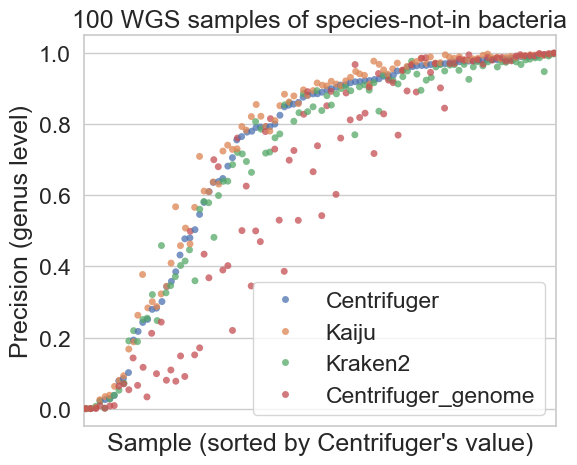

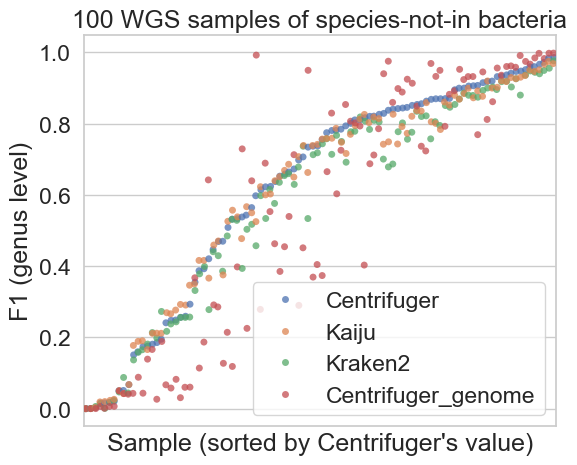

In [ ]:
for measure in ["sensitivity", "precision", "f1"]:
    sns.set(font_scale=1.5, style="whitegrid")
    fig = plt.figure(figsize=(6, 5))
    subdf = df[ df["method"] == "Centrifuger" ]
    sraList = list(subdf.sort_values(by=measure)["SRA"])
    ax = sns.stripplot(x="SRA", y = measure, hue="method", size=5, alpha=0.75,
                order = sraList, hue_order = classifierOrder + ["Centrifuger_genome"], data=df)
    ax.get_xaxis().set_ticks([])
    ax.set(xlabel = "Sample (sorted by Centrifuger's value)", title="100 WGS samples of species-not-in bacteria",
          ylabel = "%s (genus level)"%(measure.capitalize()))
    if (measure == "sensitivity"):
        ax.legend([],[], frameon=False)
    else:
        ax.legend()
    plt.tight_layout()
    plt.savefig("SRA_%s_%s.png"%(case, measure), dpi=300)
    plt.show()

# single-cell RNA-seq: SARS-CoV-2 data

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation

In [3]:
sc.__version__

/var/folders/c8/zsnj8w1x221_yh1cvqwq68n80000gn/T/ipykernel_45697/4147423214.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc.__version__


'1.12'

In [5]:
# Load processed adata
adata = sc.read_h5ad("scRNA-seq/SRR11181956_processed.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 16851 × 20410
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'leiden', 'celltypist', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'celltypist_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [7]:
adata = sc.read_10x_h5("scRNA-seq/SRR11181956_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()

/Users/lsong/miniconda3/envs/scanpy/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [9]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 19956 × 38606
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

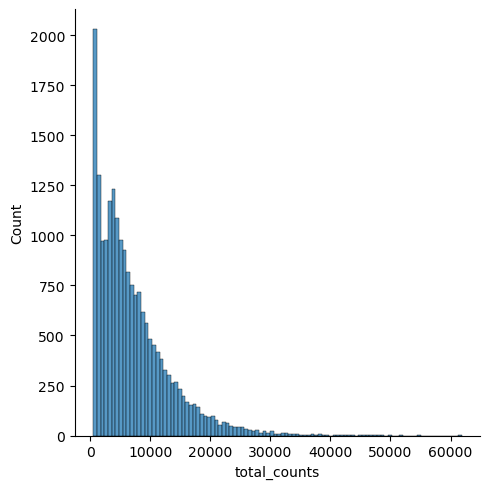

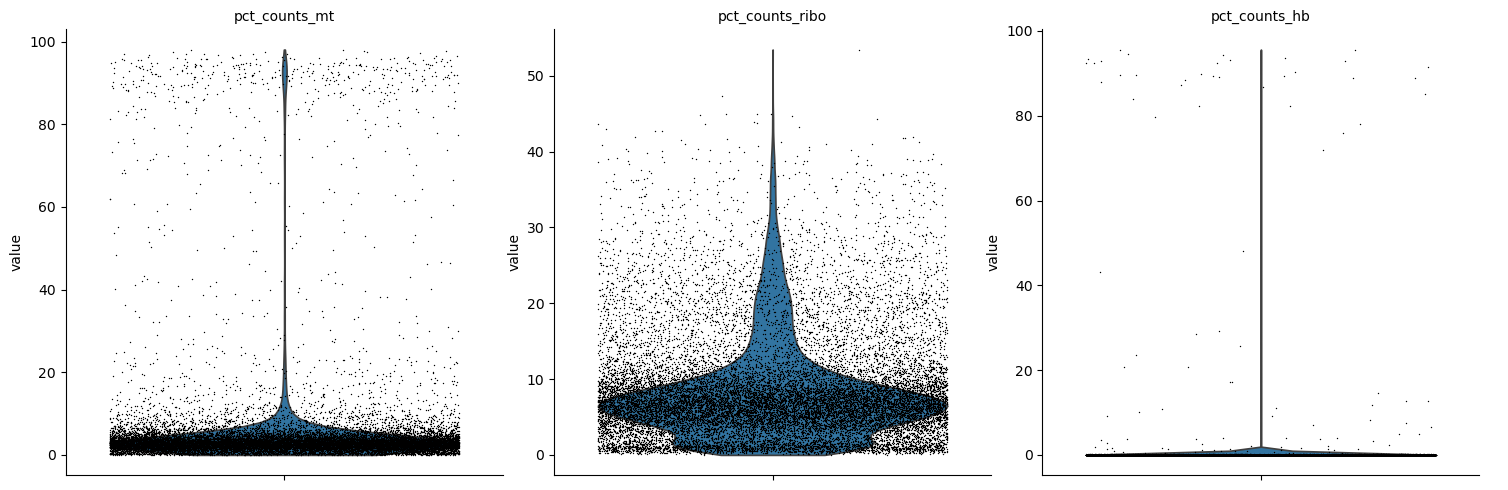

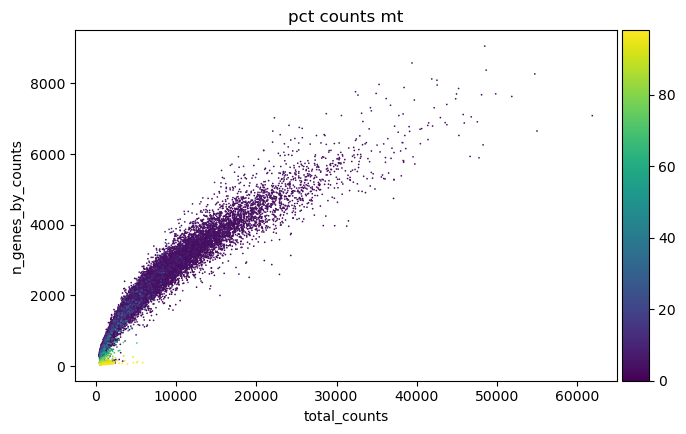

In [10]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"], jitter=0.4, multi_panel=True)
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
def is_outlier(adata, metric: str, nmads: int = 5) -> pd.Series:
    """Flag cells whose metric deviates > nmads MADs from the median."""
    m   = adata.obs[metric]
    mad = median_abs_deviation(m)
    outlier = (m < np.median(m) - nmads * mad) | \
              (m > np.median(m) + nmads * mad)
    print(np.median(m) + nmads * mad)
    print(np.median(m) - nmads * mad)
    return outlier

adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts",      nmads=5) |
    is_outlier(adata, "log1p_n_genes_by_counts", nmads=5) |
    is_outlier(adata, "pct_counts_mt",           nmads=3)
)

# Hard upper cap on mitochondrial fraction
adata.obs["mt_outlier"] = (
    is_outlier(adata, "pct_counts_mt", nmads=3) |
    (adata.obs["pct_counts_mt"] > 8)
)

11.702529
5.542918
9.65718596404155
5.547616707290086
5.7473755
-0.1824925
5.7473755
-0.1824925


In [12]:
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

In [13]:
sc.pp.filter_genes(adata, min_cells=20)

In [24]:
adata

AnnData object with n_obs × n_vars = 17543 × 20410
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [25]:
sc.pp.scrublet(adata, expected_doublet_rate=0.12)

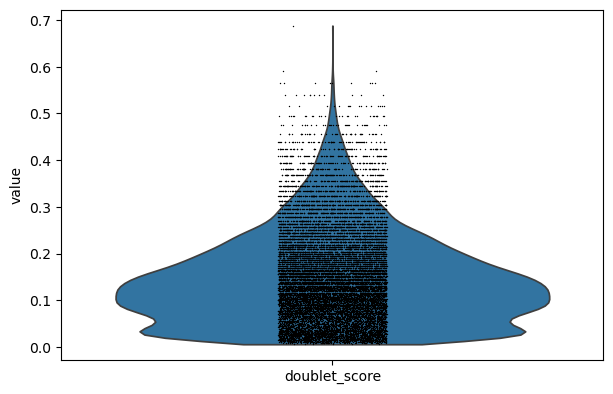

In [26]:
sc.pl.violin(adata, "doublet_score")

In [27]:
adata.obs[adata.obs["predicted_doublet"]]

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,doublet_score,predicted_doublet


In [28]:
adata[~adata.obs["predicted_doublet"]]

View of AnnData object with n_obs × n_vars = 17543 × 20410
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'

In [29]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [30]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)

/var/folders/c8/zsnj8w1x221_yh1cvqwq68n80000gn/T/ipykernel_45697/872752024.py:1: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)


In [31]:
sc.pp.pca(adata, n_comps=50, random_state=17, mask_var="highly_variable")

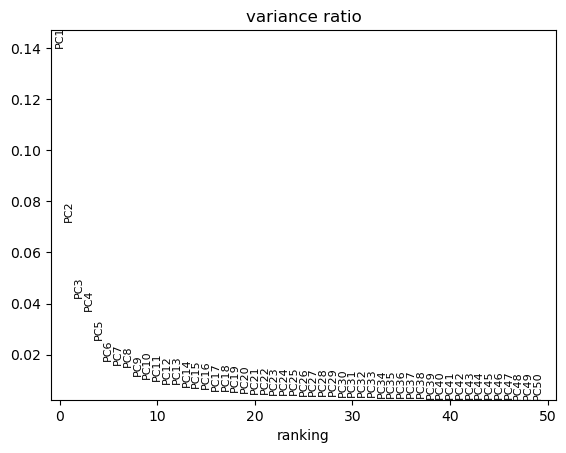

In [32]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

In [34]:
sc.pp.neighbors(adata, random_state=17)
sc.tl.umap(adata, random_state=17)

/Users/lsong/miniconda3/envs/scanpy/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [178]:
adata = adata[~adata.obs["predicted_doublet"]].copy()

In [37]:
sc.tl.leiden(adata, random_state=17)

/var/folders/c8/zsnj8w1x221_yh1cvqwq68n80000gn/T/ipykernel_45697/2353900582.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, random_state=17)


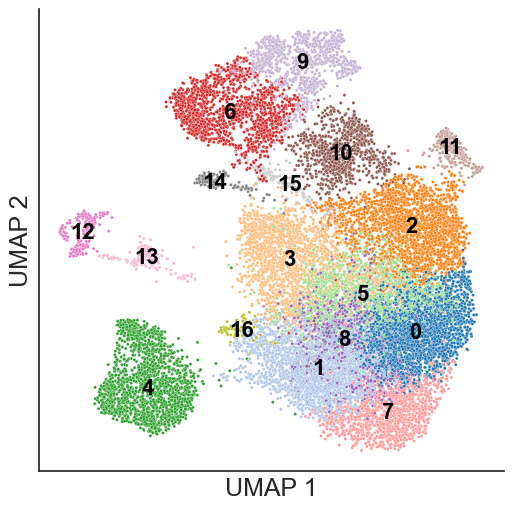

In [38]:
# FINAL MAIN FIGURE
sns.set(style="white", font_scale=1.5)
_, ax = plt.subplots(figsize=(6, 6))

#sc.pl.umap(adata, color="leiden", legend_loc="on data",
#    ax=ax, show=False)
ax = sns.scatterplot(x=adata.obsm["X_umap"][:,0], y=adata.obsm["X_umap"][:,1],
                 hue=adata.obs["leiden"], palette="tab20", s=5, ax=ax,
                 rasterized=True, legend=False)

# Draw the cluster labels on the UMAP plot
for i, label in enumerate(adata.obs["leiden"].cat.categories):
    x = np.median(adata.obsm["X_umap"][adata.obs["leiden"] == label, 0])
    y = np.median(adata.obsm["X_umap"][adata.obs["leiden"] == label, 1])
    ax.text(x, y, label, fontsize=16, fontweight="bold", color="black",
            horizontalalignment="center", verticalalignment="center")

ax.set(xlabel="UMAP 1", ylabel="UMAP 2")
# Hide top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Hide x and y ticks
ax.set_xticks([])
ax.set_yticks([])

plt.savefig("scRNA-seq/SRR11181956_umap_leiden.pdf", format="pdf", bbox_inches="tight", dpi=600)

In [40]:
sc.tl.rank_genes_groups(adata, groupby="leiden", 
                        method="wilcoxon", n_genes=adata.n_vars,
                        random_state=17)

In [39]:
adata

AnnData object with n_obs × n_vars = 17543 × 20410
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'predicted_doublet_colors', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

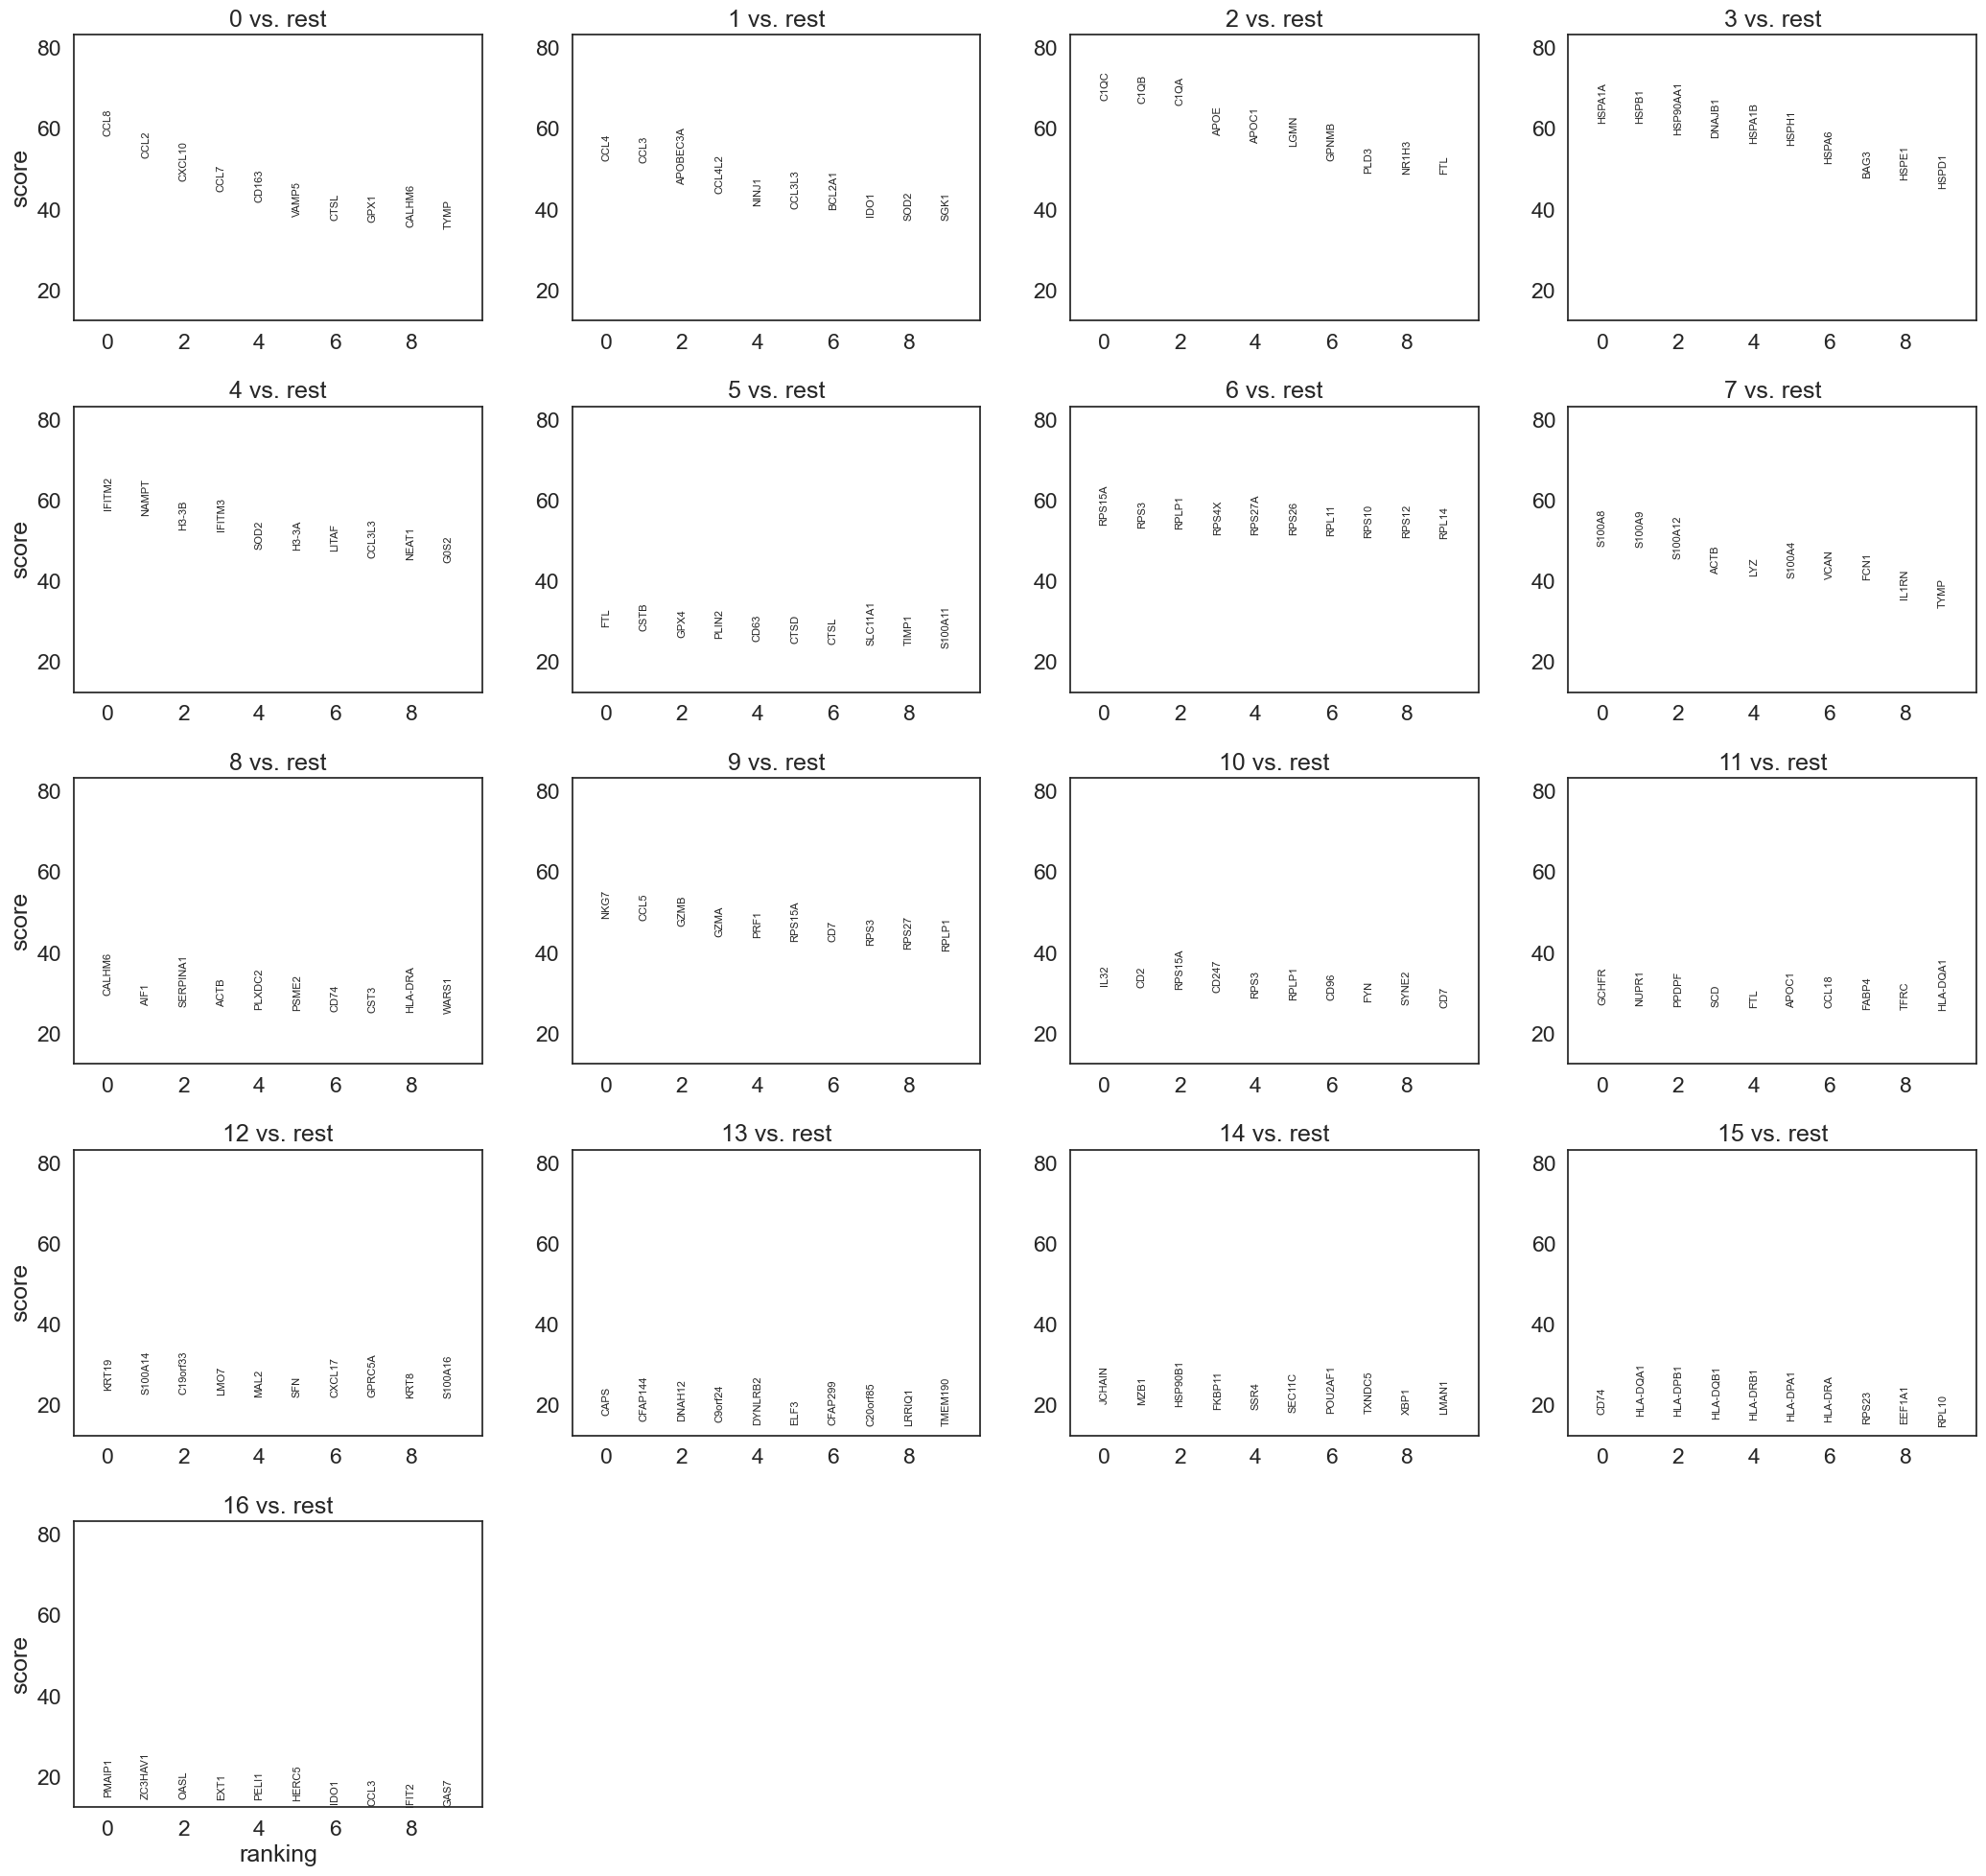

In [41]:
sc.pl.rank_genes_groups(
    adata,
    key="rank_genes_groups",
    n_genes=10)

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    key="rank_genes_groups",
    n_genes=5,
    groupby="leiden", swap_axes=True)

In [44]:
adata.write_h5ad("scRNA-seq/SRR11181956_processed.h5ad")

## Cell type annotation

In [45]:
import celltypist

/Users/lsong/miniconda3/envs/scanpy/lib/python3.14/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [46]:
celltypist.__version__

'1.7.1'

In [130]:
from celltypist import models

In [131]:
models.download_models(force_update=True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /Users/lsong/.celltypist/data/models
💾 Downloading model [1/60]: Immune_All_Low.pkl
💾 Downloading model [2/60]: Immune_All_High.pkl
💾 Downloading model [3/60]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/60]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/60]: Adult_Human_MTG.pkl
💾 Downloading model [6/60]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/60]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/60]: Adult_Human_Skin.pkl
💾 Downloading model [9/60]: Adult_Human_Vascular.pkl
💾 Downloading model [10/60]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/60]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/60]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/60]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/60]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/60]: Adult_cHSPCs_Ultima.pkl
💾 Do

In [47]:
predictions= celltypist.annotate(adata, model="COVID19_Immune_Landscape.pkl", 
                                 over_clustering = "leiden", majority_voting=True)

🔬 Input data has 17543 cells and 20410 genes
🔗 Matching reference genes in the model
🧬 2800 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


In [48]:
adata.obs["celltypist"] = predictions.predicted_labels.loc[adata.obs.index, "majority_voting"]

[Text(0.5, 1.0, 'CellTypist\nCOVID19_Immune_Landscape model')]

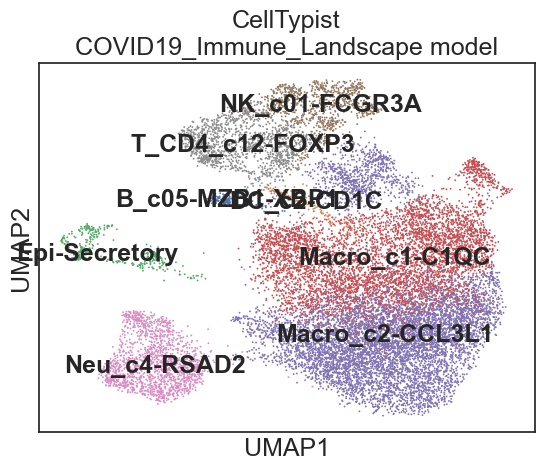

In [ ]:
ax = sc.pl.umap(adata, color="celltypist", legend_loc="on data", show=False,)
ax.set(title="CellTypist\nCOVID19_Immune_Landscape model")

In [51]:
# Get the leiden to celltypist mapping from adata.obs
leiden_to_celltypist = adata.obs.groupby("leiden")["celltypist"].agg(lambda x: x.value_counts().index[0])
leiden_to_celltypist

leiden
0     Macro_c2-CCL3L1
1     Macro_c2-CCL3L1
2       Macro_c1-C1QC
3       Macro_c1-C1QC
4        Neu_c4-RSAD2
5       Macro_c1-C1QC
6     T_CD4_c12-FOXP3
7     Macro_c2-CCL3L1
8     Macro_c2-CCL3L1
9       NK_c01-FCGR3A
10    Macro_c2-CCL3L1
11      Macro_c1-C1QC
12      Epi-Secretory
13      Epi-Secretory
14    B_c05-MZB1-XBP1
15         DC_c2-CD1C
16    Macro_c2-CCL3L1
Name: celltypist, dtype: category
Categories (8, object): ['B_c05-MZB1-XBP1', 'DC_c2-CD1C', 'Epi-Secretory', 'Macro_c1-C1QC', 'Macro_c2-CCL3L1', 'NK_c01-FCGR3A', 'Neu_c4-RSAD2', 'T_CD4_c12-FOXP3']

In [56]:
# Get the leiden to celtype mapping from adata.obs
adata.obs["leiden"].unique()
leiden_to_celltype = {
    "0": "myeloid",
    "1": "myeloid",
    "2": "myeloid",
    "3": "myeloid",
    "4": "myeloid",
    "5": "myeloid",
    "6": "lymphoid",
    "7": "myeloid",
    "8": "myeloid",
    "9": "lymphoid",
    "10": "myeloid",
    "11": "myeloid",
    "12": "epithelial",
    "13": "epithelial",
    "14": "lymphoid",
    "15": "myeloid",
    "16": "myeloid"}
adata.obs["coarse_celltype"] = adata.obs["leiden"].map(leiden_to_celltype)

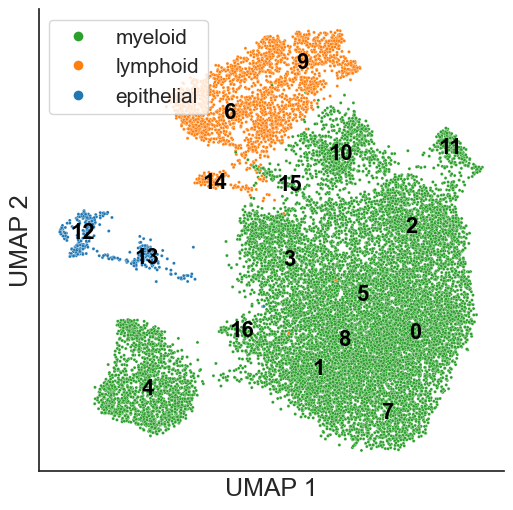

In [67]:
# Draw UMAP with color of the coarse cell type and the annoation from leiden cluster
fig, ax = plt.subplots(figsize=(6, 6))
#ax = sc.pl.umap(adata, color="leiden", legend_loc="on data", size=0, show=False, ax=ax)
#ax = sc.pl.umap(adata, color="coarse_celltype", show=False, ax=ax,
#    legend_loc="lower right")
palette = sns.color_palette("tab10")
palette[0], palette[2] = palette[2], palette[0]
ax = sns.scatterplot(x=adata.obsm["X_umap"][:,0], y=adata.obsm["X_umap"][:,1],
                 hue=adata.obs["coarse_celltype"], s=5, ax=ax, palette=palette,
                 rasterized=True, legend=False)

# Draw the cluster labels on the UMAP plot
for i, label in enumerate(adata.obs["leiden"].cat.categories):
    x = np.median(adata.obsm["X_umap"][adata.obs["leiden"] == label, 0])
    y = np.median(adata.obsm["X_umap"][adata.obs["leiden"] == label, 1])
    ax.text(x, y, label, fontsize=16, fontweight="bold", color="black",
            horizontalalignment="center", verticalalignment="center")

ax.set(xlabel="UMAP 1", ylabel="UMAP 2")
# Hide top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Hide x and y ticks
ax.set_xticks([])
ax.set_yticks([])

ax.set(title="")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_rasterized(True)

# Add the legend, start from creating the dot element
legend = {
    "myeloid": palette[0],
    "lymphoid": palette[1],
    "epithelial": palette[2]
}
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', 
    markerfacecolor=legend[celltype], markersize=8) for celltype in legend]
ax.legend(handles=legend_handles, labels=legend.keys(), loc="upper left", fontsize=15)


plt.savefig("scRNA-seq/SRR11181956_umap_coarse_celltype.pdf", format="pdf", bbox_inches="tight", dpi=600)


## Overlay with Centrifuger result

In [68]:
sarscov2ReadIds = {}
with open("scRNA-seq/cfr_class_nr_2697049.tsv") as f:
    for line in f:
        cols = line.strip().split("\t")
        if (len(cols) < 9):
            continue
        sarscov2ReadIds[cols[0]] = cols[8]

In [70]:
# Create a dataframe counting the number of reads classified as SARS-CoV-2 for each cell
sarscov2BarcodeReadCounts = {}
for readId, barcode in sarscov2ReadIds.items():
    if (barcode not in sarscov2BarcodeReadCounts):
        sarscov2BarcodeReadCounts[barcode] = 0
    sarscov2BarcodeReadCounts[barcode] += 1
sarscov2Df = pd.DataFrame({"barcode": list(sarscov2BarcodeReadCounts.keys()),
                            "sarscov2_read_count": list(sarscov2BarcodeReadCounts.values())})
sarscov2Df.set_index("barcode", inplace=True)
# Merge the SARS-CoV-2 read counts with the adata.obs dataframe
adata.obs = adata.obs.merge(sarscov2Df, left_index=True, right_index=True, how="left")
adata.obs["sarscov2_read_count"] = adata.obs["sarscov2_read_count"].fillna(0)

... storing 'coarse_celltype' as categorical


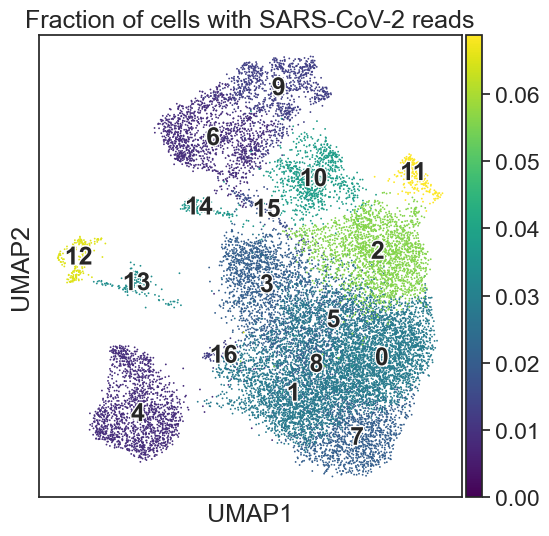

In [72]:
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(adata, color="leiden", legend_loc="on data", return_fig=False, ax=ax, show=False,
           legend_fontoutline=2, size=0)
sc.pl.umap(adata, color="cluster_sarscov2_fraction", vmin=0, color_map="viridis", ax=ax, show=False)
ax.set(title="Fraction of cells with SARS-CoV-2 reads", rasterized=True)
plt.savefig("scRNA-seq/SRR11181956_umap_sarscov2_fraction.pdf", format="pdf", bbox_inches="tight", dpi=600)

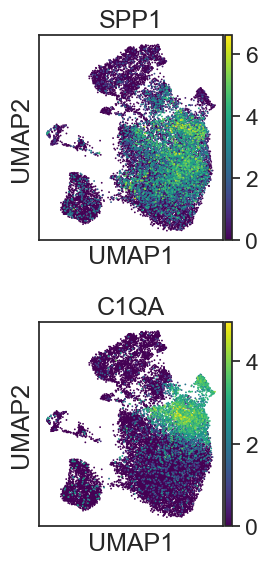

In [83]:
fig, axes = plt.subplots(figsize=(3, 6), nrows=2, ncols=1)
for i, gene in enumerate(["SPP1", "C1QA"]):
    ax = axes[i]
    sc.pl.umap(adata, color=[gene], vmin=0, color_map="viridis", show=False, ax=ax)
    ax.set_rasterized(True)
plt.tight_layout()
plt.savefig("scRNA-seq/SRR11181956_umap_SPP1_C1QA.pdf", format="pdf", bbox_inches="tight", dpi=600)


In [74]:
# Overlap with the reads from YP_009724397.2
ypBarcodes = {}
with open("scRNA-seq/YP_009724397.2_readids.out") as f:
    for line in f:
        readId = line.strip()
        if (readId not in sarscov2ReadIds): # Some read id does not have valid barcode
            continue
        barcode = sarscov2ReadIds[readId]
        if (barcode not in ypBarcodes):
            ypBarcodes[barcode] = 0
        ypBarcodes[barcode] += 1

In [75]:
ypDf = pd.DataFrame({"barcode": list(ypBarcodes.keys()),
                            "YP_009724397.2_read_count": list(ypBarcodes.values())})
ypDf.set_index("barcode", inplace=True)
# Merge the SARS-CoV-2 read counts with the adata.obs dataframe
adata.obs = adata.obs.merge(ypDf, left_index=True, right_index=True, how="left")
adata.obs["YP_009724397.2_read_count"] = adata.obs["YP_009724397.2_read_count"].fillna(0)

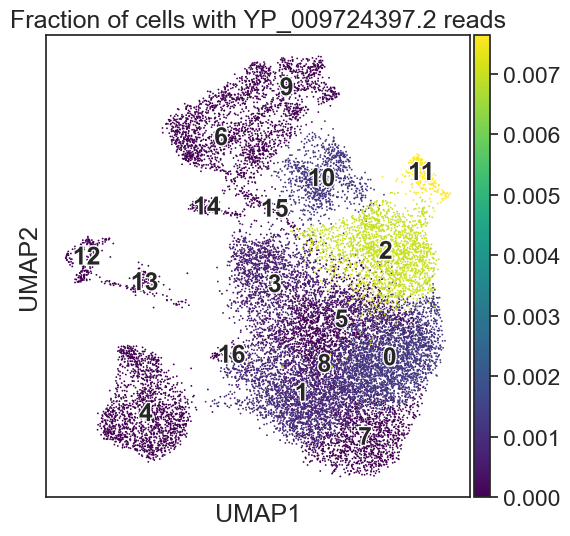

In [77]:
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(adata, color="leiden", legend_loc="on data", return_fig=False, ax=ax, show=False,
           legend_fontoutline=2, s=0)
sc.pl.umap(adata, color="cluster_YP_009724397_fraction", vmin=0, color_map="viridis", ax=ax, show=False)
ax.set(title="Fraction of cells with YP_009724397.2 reads", rasterized=True)
plt.savefig("scRNA-seq/SRR11181956_umap_YP_009724397_fraction.pdf", format="pdf", bbox_inches="tight", dpi=600)
#plt.show()

In [79]:
# Overlap with the reads from WCL51902.1
wclBarcodes = {}
with open("scRNA-seq/WCL51902.1_readids.out") as f:
    for line in f:
        readId = line.strip()
        if (readId not in sarscov2ReadIds): # Some read id does not have valid barcode
            continue
        barcode = sarscov2ReadIds[readId]
        if (barcode not in wclBarcodes):
            wclBarcodes[barcode] = 0
        wclBarcodes[barcode] += 1

In [80]:
# Create a DataFrame for WCL51902.1 read counts
wclDf = pd.DataFrame({"barcode": list(wclBarcodes.keys()),
                            "WCL51902.1_read_count": list(wclBarcodes.values())})
wclDf.set_index("barcode", inplace=True)
# Merge the SARS-CoV-2 read counts with the adata.obs dataframe
adata.obs = adata.obs.merge(wclDf, left_index=True, right_index=True, how="left")
adata.obs["WCL51902.1_read_count"] = adata.obs["WCL51902.1_read_count"].fillna(0)

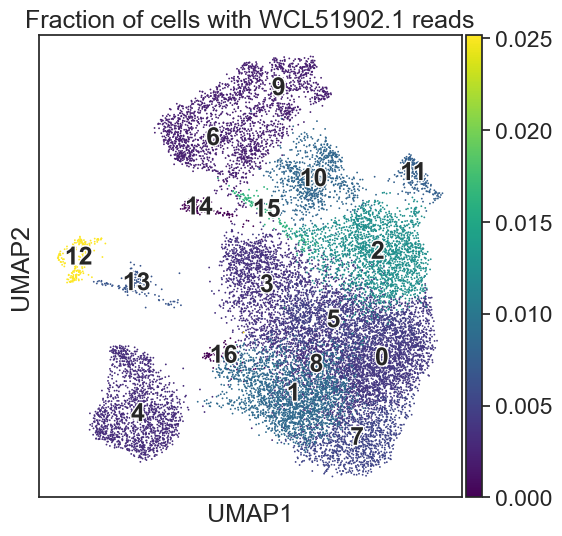

In [82]:
sns.set(font_scale=1.5, style="white")
fig, ax = plt.subplots(figsize=(6, 6))
sc.pl.umap(adata, color="leiden", legend_loc="on data", return_fig=False, ax=ax, show=False,
           legend_fontoutline=2, s=0)
#sc.pl.umap(adata, color="cluster_YP_009724397_fraction", vmin=0, color_map="viridis", ax=ax, show=False)
sc.pl.umap(adata, color="cluster_WCL51902.1_fraction", vmin=0, color_map="viridis", ax=ax, show=False)
ax.set(title="Fraction of cells with WCL51902.1 reads", rasterized=True)
plt.savefig("scRNA-seq/SRR11181956_umap_WCL51902.1_fraction.pdf", format="pdf", bbox_inches="tight", dpi=600)
#plt.show()